In [57]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

DATA_PATH = Path("../data/processed/gaming_option_a_processed.csv")
df = pd.read_csv(DATA_PATH)

df.head()

,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,exercise_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,3.7,383.70,3,Severe
1,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,8.5,46.64,1,Low
2,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,7.1,100.81,6,Severe
3,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,5.2,51.60,7,High
4,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,6.1,32.57,1,Moderate


In [58]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nTarget distribution:")
print(df["gaming_addiction_risk_level"].value_counts())

Shape: (1000, 13)

Columns:
['age', 'gender', 'daily_gaming_hours', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality', 'sleep_disruption_frequency', 'exercise_hours_weekly', 'monthly_game_spending_usd', 'years_gaming', 'gaming_addiction_risk_level']

Missing values:
age                            0
gender                         0
daily_gaming_hours             0
game_genre                     0
primary_game                   0
gaming_platform                0
sleep_hours                    0
sleep_quality                  0
sleep_disruption_frequency     0
exercise_hours_weekly          0
monthly_game_spending_usd      0
years_gaming                   0
gaming_addiction_risk_level    0
dtype: int64

Target distribution:
gaming_addiction_risk_level
Low         514
Moderate    190
High        154
Severe      142
Name: count, dtype: int64


In [59]:
target = "gaming_addiction_risk_level"

X = df.drop(columns=[target])
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 12)
y shape: (1000,)


In [60]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: ['High' 'Low' 'Moderate' 'Severe']


In [61]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['age', 'daily_gaming_hours', 'sleep_hours', 'exercise_hours_weekly', 'monthly_game_spending_usd', 'years_gaming']

Categorical columns:
['gender', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_quality', 'sleep_disruption_frequency']


In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 12)
X_test: (200, 12)
y_train: (800,)
y_test: (200,)


In [63]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Logistic Regression

In [64]:
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logreg_model.fit(X_train, y_train)

y_pred_logreg = logreg_model.predict(X_test)

logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_f1 = f1_score(y_test, y_pred_logreg, average="macro")

print("Logistic Regression Accuracy:", round(logreg_accuracy, 4))
print("Logistic Regression Macro F1:", round(logreg_f1, 4))
print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_logreg, target_names=label_encoder.classes_))

Logistic Regression Accuracy: 0.67
Logistic Regression Macro F1: 0.5474

Logistic Regression Classification Report:

              precision    recall  f1-score   support

        High       0.36      0.26      0.30        31
         Low       0.86      0.91      0.89       103
    Moderate       0.36      0.42      0.39        38
      Severe       0.67      0.57      0.62        28

    accuracy                           0.67       200
   macro avg       0.56      0.54      0.55       200
weighted avg       0.66      0.67      0.66       200



d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


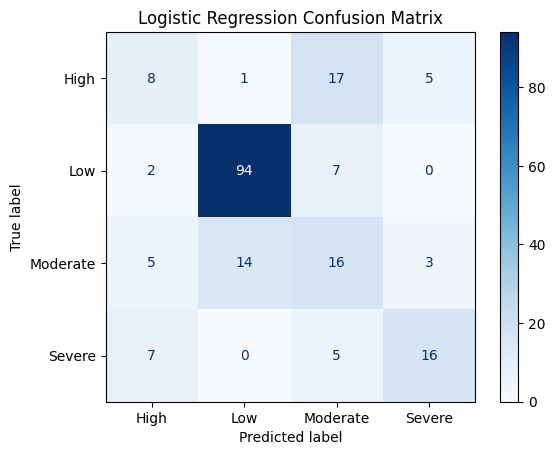

In [65]:
import matplotlib.pyplot as plt

cm_logreg = confusion_matrix(y_test, y_pred_logreg)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=label_encoder.classes_
)
disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Random Forest


In [66]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average="macro")

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest Macro F1:", round(rf_f1, 4))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Random Forest Accuracy: 0.695
Random Forest Macro F1: 0.5957

Random Forest Classification Report:

              precision    recall  f1-score   support

        High       0.41      0.35      0.38        31
         Low       0.86      0.90      0.88       103
    Moderate       0.39      0.39      0.39        38
      Severe       0.74      0.71      0.73        28

    accuracy                           0.69       200
   macro avg       0.60      0.59      0.60       200
weighted avg       0.69      0.69      0.69       200



# Compare Models

In [67]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logreg_accuracy, rf_accuracy],
    "Macro F1": [logreg_f1, rf_f1]
})

results.sort_values(by="Macro F1", ascending=False)

,Model,Accuracy,Macro F1
1,Random Forest,0.695,0.595709
0,Logistic Regression,0.670,0.547402
